# 07 — Hyperparameter Sweep: lambda_hrf and Epoch Count

v1/v2 used untuned defaults (`lambda_hrf=0.1`, 5 fixed epochs — see
[docs/ml-design-report.md §4](../docs/ml-design-report.md#4-loss-and-optimization-design)).
This notebook runs two sweeps on the 20-subject dataset:

1. **lambda_hrf** in `[0.0, 0.05, 0.1, 0.3, 1.0]`, for the two multi-task
   experiments (GRU, Transformer), 5 epochs fixed.
2. **epoch count** in `[5, 10, 15, 20]`, for all four experiments,
   `lambda_hrf=0.1` fixed — checking whether the v2 result (val macro F1
   plateauing by epoch 4-5) actually holds past epoch 5.

All other hyperparameters (lr, weight_decay, batch_size, seed) match the
main ladder for comparability.


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.engine import TrainConfig, train_experiment
from neurolens.model_builder import GRUDecoder, TransformerDecoder

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"

SEED = 42
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 64


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)


train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=BATCH_SIZE)
print({k: v for k, v in info.items() if k != "class_weights"})


{'num_classes': 6, 'num_conditions': 5, 'n_train_windows': 3556, 'n_val_windows': 762, 'n_test_windows': 762, 'class_to_condition': {'0': 'baseline', '1': 'left_hand', '2': 'right_hand', '3': 'left_foot', '4': 'right_foot', '5': 'tongue'}, 'condition_names': ['left_hand', 'right_hand', 'left_foot', 'right_foot', 'tongue']}


## 1. Sweep: lambda_hrf (multi-task experiments only, 5 epochs)

In [2]:
LAMBDA_VALUES = [0.0, 0.05, 0.1, 0.3, 1.0]

lambda_sweep_results = []
for encoder_name, model_fn in [
    ("GRU", lambda: GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
    ("Transformer", lambda: TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
]:
    for lam in LAMBDA_VALUES:
        set_seed(SEED)
        model = model_fn()
        config = TrainConfig(
            experiment_name=f"lambda_sweep_{encoder_name}_{lam}",
            num_epochs=5, lr=LR, weight_decay=WEIGHT_DECAY, lambda_hrf=lam,
            checkpoint_dir=None,
        )
        result = train_experiment(model, train_loader, val_loader, test_loader, info["num_classes"], info["class_weights"], config)
        tm = result["test_metrics"]
        lambda_sweep_results.append({
            "encoder": encoder_name, "lambda_hrf": lam,
            "test_macro_f1": tm["macro_f1"], "test_balanced_accuracy": tm["balanced_accuracy"],
            "test_hrf_mse": tm["hrf_mse"], "test_hrf_mae": tm["hrf_mae"],
            "best_val_macro_f1": result["best_val_macro_f1"],
        })
        print(encoder_name, "lambda_hrf=", lam, "-> test macro F1", round(tm["macro_f1"], 4), "hrf_mse", tm["hrf_mse"])

lambda_sweep_df = pd.DataFrame(lambda_sweep_results)
lambda_sweep_df


[lambda_sweep_GRU_0.0] epoch 1/5 lr=1.00e-03 train_loss=1.0019 val_loss=0.5709 val_macro_f1=0.8291


[lambda_sweep_GRU_0.0] epoch 2/5 lr=9.05e-04 train_loss=0.2676 val_loss=0.4270 val_macro_f1=0.8621


[lambda_sweep_GRU_0.0] epoch 3/5 lr=6.55e-04 train_loss=0.1263 val_loss=0.4483 val_macro_f1=0.8492


[lambda_sweep_GRU_0.0] epoch 4/5 lr=3.45e-04 train_loss=0.0796 val_loss=0.4526 val_macro_f1=0.8506


[lambda_sweep_GRU_0.0] epoch 5/5 lr=9.55e-05 train_loss=0.0628 val_loss=0.4455 val_macro_f1=0.8491


...

[lambda_sweep_Transformer_1.0] epoch 2/5 lr=9.05e-04 train_loss=0.2843 val_loss=0.5128 val_macro_f1=0.8385


[lambda_sweep_Transformer_1.0] epoch 3/5 lr=6.55e-04 train_loss=0.1471 val_loss=0.4840 val_macro_f1=0.8666


[lambda_sweep_Transformer_1.0] epoch 4/5 lr=3.45e-04 train_loss=0.0804 val_loss=0.4813 val_macro_f1=0.8576


[lambda_sweep_Transformer_1.0] epoch 5/5 lr=9.55e-05 train_loss=0.0528 val_loss=0.4784 val_macro_f1=0.8667
Transformer lambda_hrf= 1.0 -> test macro F1 0.9185 hrf_mse 0.019428232684731483


,encoder,lambda_hrf,test_macro_f1,test_balanced_accuracy,test_hrf_mse,test_hrf_mae,best_val_macro_f1
0,GRU,0.00,0.911929,0.911202,0.342291,0.433538,0.862104
1,GRU,0.05,0.911886,0.911100,0.048774,0.171147,0.863519
2,GRU,0.10,0.910635,0.909676,0.047647,0.168940,0.864950
3,GRU,0.30,0.908050,0.907094,0.044286,0.162205,0.866301
4,GRU,1.00,0.910648,0.909409,0.039064,0.150836,0.862506
5,Transformer,0.00,0.921178,0.921386,0.347925,0.483813,0.875569
6,Transformer,0.05,0.922399,0.922811,0.041641,0.154864,0.876150
7,Transformer,0.10,0.925194,0.925231,0.036306,0.142822,0.876248
8,Transformer,0.30,0.922494,0.922379,0.026159,0.114787,0.873072
9,Transformer,1.00,0.918480,0.918045,0.019428,0.092960,0.866676


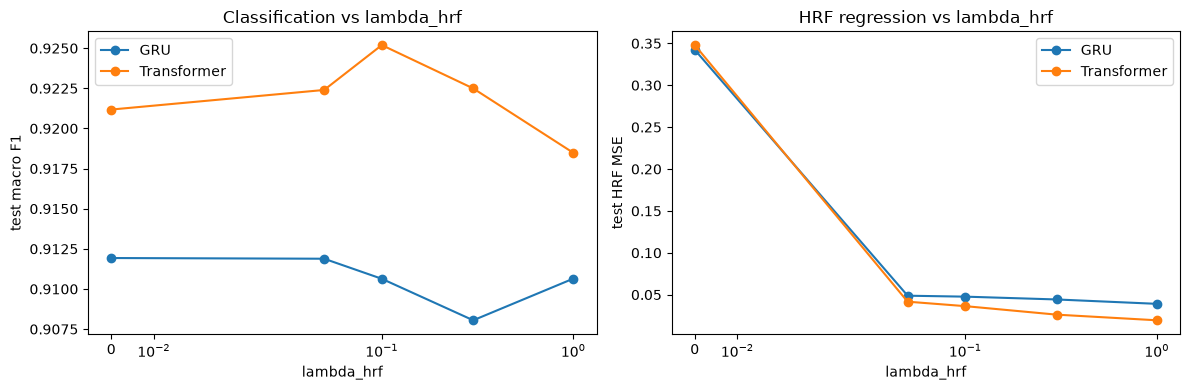

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for encoder_name, group in lambda_sweep_df.groupby("encoder"):
    axes[0].plot(group["lambda_hrf"], group["test_macro_f1"], marker="o", label=encoder_name)
    axes[1].plot(group["lambda_hrf"], group["test_hrf_mse"], marker="o", label=encoder_name)

axes[0].set_xlabel("lambda_hrf"); axes[0].set_ylabel("test macro F1"); axes[0].set_title("Classification vs lambda_hrf")
axes[0].set_xscale("symlog", linthresh=0.05); axes[0].legend()
axes[1].set_xlabel("lambda_hrf"); axes[1].set_ylabel("test HRF MSE"); axes[1].set_title("HRF regression vs lambda_hrf")
axes[1].set_xscale("symlog", linthresh=0.05); axes[1].legend()
fig.tight_layout()
plt.show()


## 2. Sweep: epoch count (all 4 experiments, lambda_hrf=0.1)

In [4]:
EPOCH_VALUES = [5, 10, 15, 20]

EXPERIMENTS = [
    ("GRU_cls_only", lambda: GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)),
    ("GRU_multitask", lambda: GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
    ("Transformer_cls_only", lambda: TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)),
    ("Transformer_multitask", lambda: TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
]

epoch_sweep_results = []
for exp_name, model_fn in EXPERIMENTS:
    for n_epochs in EPOCH_VALUES:
        set_seed(SEED)
        model = model_fn()
        config = TrainConfig(
            experiment_name=f"epoch_sweep_{exp_name}_{n_epochs}",
            num_epochs=n_epochs, lr=LR, weight_decay=WEIGHT_DECAY, lambda_hrf=0.1,
            checkpoint_dir=None,
        )
        result = train_experiment(model, train_loader, val_loader, test_loader, info["num_classes"], info["class_weights"], config)
        tm = result["test_metrics"]
        epoch_sweep_results.append({
            "experiment": exp_name, "num_epochs": n_epochs,
            "test_macro_f1": tm["macro_f1"], "test_balanced_accuracy": tm["balanced_accuracy"],
            "best_val_macro_f1": result["best_val_macro_f1"],
        })
        print(exp_name, "epochs=", n_epochs, "-> test macro F1", round(tm["macro_f1"], 4))

epoch_sweep_df = pd.DataFrame(epoch_sweep_results)
epoch_sweep_df


[epoch_sweep_GRU_cls_only_5] epoch 1/5 lr=1.00e-03 train_loss=1.0106 val_loss=0.5785 val_macro_f1=0.8138


[epoch_sweep_GRU_cls_only_5] epoch 2/5 lr=9.05e-04 train_loss=0.2806 val_loss=0.4498 val_macro_f1=0.8510


[epoch_sweep_GRU_cls_only_5] epoch 3/5 lr=6.55e-04 train_loss=0.1325 val_loss=0.4241 val_macro_f1=0.8543


[epoch_sweep_GRU_cls_only_5] epoch 4/5 lr=3.45e-04 train_loss=0.0833 val_loss=0.4296 val_macro_f1=0.8605


[epoch_sweep_GRU_cls_only_5] epoch 5/5 lr=9.55e-05 train_loss=0.0661 val_loss=0.4252 val_macro_f1=0.8552
GRU_cls_only epochs= 5 -> test macro F1 0.9118


...

[epoch_sweep_Transformer_multitask_20] epoch 17/20 lr=9.55e-05 train_loss=0.0031 val_loss=0.5805 val_macro_f1=0.8795


[epoch_sweep_Transformer_multitask_20] epoch 18/20 lr=5.45e-05 train_loss=0.0030 val_loss=0.5803 val_macro_f1=0.8807


[epoch_sweep_Transformer_multitask_20] epoch 19/20 lr=2.45e-05 train_loss=0.0030 val_loss=0.5797 val_macro_f1=0.8820


[epoch_sweep_Transformer_multitask_20] epoch 20/20 lr=6.16e-06 train_loss=0.0030 val_loss=0.5798 val_macro_f1=0.8820
Transformer_multitask epochs= 20 -> test macro F1 0.9159


,experiment,num_epochs,test_macro_f1,test_balanced_accuracy,best_val_macro_f1
0,GRU_cls_only,5,0.911820,0.909790,0.860480
1,GRU_cls_only,10,0.903788,0.902306,0.854931
2,GRU_cls_only,15,0.902499,0.901043,0.856408
3,GRU_cls_only,20,0.903515,0.901624,0.855401
4,GRU_multitask,5,0.910635,0.909676,0.864950
5,GRU_multitask,10,0.909265,0.908353,0.868894
6,GRU_multitask,15,0.909265,0.908353,0.868904
7,GRU_multitask,20,0.910539,0.909676,0.868904
8,Transformer_cls_only,5,0.920032,0.918439,0.854848
9,Transformer_cls_only,10,0.922418,0.921819,0.872319


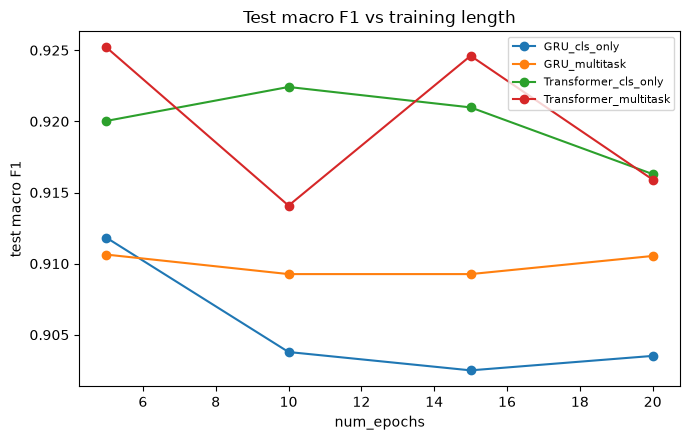

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for exp_name, group in epoch_sweep_df.groupby("experiment"):
    ax.plot(group["num_epochs"], group["test_macro_f1"], marker="o", label=exp_name)
ax.set_xlabel("num_epochs"); ax.set_ylabel("test macro F1"); ax.set_title("Test macro F1 vs training length")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 3. Save consolidated sweep results

In [6]:
summary = {
    "lambda_sweep": lambda_sweep_df.to_dict(orient="records"),
    "epoch_sweep": epoch_sweep_df.to_dict(orient="records"),
}
sweep_path = RESULTS_DIR / "hyperparameter_sweep_results.json"
with open(sweep_path, "w") as f:
    json.dump(summary, f, indent=2)
print("saved:", sweep_path)


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/hyperparameter_sweep_results.json


## Summary

**lambda_hrf sweep** (5 epochs, both multi-task experiments):
- Classification is fairly robust to lambda_hrf across [0.0, 0.05, 0.1, 0.3, 1.0] for both encoders (GRU: 0.908-0.912; Transformer: 0.918-0.925, peaking at 0.1).
- **At lambda_hrf=0.0, HRF MSE is ~0.34-0.35 for both encoders** - essentially untrained, since a loss term multiplied by 0 contributes zero gradient to the HRF head. This confirms the auxiliary loss is *necessary*, not just beneficial, for that head to learn anything - a useful sanity check on the multi-task setup itself.
- HRF MSE improves monotonically with higher lambda_hrf for both encoders. For the **GRU, this comes at essentially zero classification cost** (macro F1 flat at ~0.91 from lambda=0.05 to 1.0, while HRF MSE drops from 0.049 to 0.039) - lambda=0.1 was leaving free HRF quality on the table. For the **Transformer, there's a real tradeoff**: lambda=0.1 is the classification sweet spot (0.925); lambda=1.0 gets the best HRF fit (MSE 0.019) but at a small classification cost (0.918).

**Epoch sweep** (lambda_hrf=0.1, all 4 experiments, up to 20 epochs):
- **More epochs did not reliably improve test performance** - 3 of 4 experiments show non-monotonic or declining test macro F1 past 5-10 epochs (e.g. Transformer multi-task: 0.925 at 5 epochs, drops to 0.914 at 10, recovers to 0.925 at 15, drops to 0.916 at 20).
- Notably, **validation macro F1 for the best checkpoint kept creeping up with more epochs even where test performance did not** (Transformer multi-task: best-val 0.876 -> 0.889 from 5 to 20 epochs) - a sign that with only 3 validation and 3 test subjects, the validation-selected best epoch doesn't reliably transfer to the test subjects. This is a **generalization-gap symptom of the subject count, not a training-length problem** - more epochs is not the lever to pull; more subjects likely is.
- 5 epochs remains a reasonable choice at this scale - not just fast, but not clearly worse than training longer.

Full numbers: [results/hyperparameter_sweep_results.json](../results/hyperparameter_sweep_results.json). Findings incorporated into [docs/case1-summary-report.md](../docs/case1-summary-report.md).
